# Steve's Luxury Resort — Churn Prediction

**MMAI 869 Team Project · Team-Union**

This notebook walks through the team's analysis: data exploration, feature engineering, modeling, and final ensemble.

**Competition:** [Steve's Luxury Resort (MMAI)](https://www.kaggle.com/competitions/steves-luxury-resort-mmai) on Kaggle.
**Metric:** F-Score (Macro)
**Deliverable:** 12-minute live presentation.

## 1. Setup

In [76]:
import sys
sys.path.insert(0, '..')

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
from pathlib import Path


#from src.data import load_raw, basic_clean, split_xy, ID_COL, TARGET
#from src.features import add_all_features

def load_churn_data():
    # Load the data from the local file, or download it if it doesn't exist
    churn_path = Path("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union/datasets/resort_train.csv")
    if not churn_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/stepthom/869_course/blob/main/data/resort_train.csv"
        urllib.request.urlretrieve(url, churn_path)
    return pd.read_csv(churn_path)

churn = load_churn_data()

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 80)

In [77]:
# extra code – code to save the figures as high-res PNGs for the book

IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [78]:
# extra code – the next 5 lines define the default font sizes of graphs
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 2. Load and inspect

The competition gives us three files:
- `resort_train.csv` — 6,954 rows × 21 columns (with `Churned` target)
- `resort_test.csv` — 1,739 rows × 20 columns
- `sample_submission.csv` — `GuestID, Churned` format with 0/1 values

In [79]:
#train_raw, test_raw, sample = load_raw()
#print(f'train: {train_raw.shape}, test: {test_raw.shape}, submission: {sample.shape}')
churn.head()

,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,Dining,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,0.000000,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,336519.843643,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,0.000000,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,0.000000,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


In [80]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GuestID         6954 non-null   int64  
 1   BookingDate     6954 non-null   object 
 2   PromoCode       3709 non-null   object 
 3   Region          6785 non-null   object 
 4   AllInclusive    6786 non-null   float64
 5   Room            6568 non-null   object 
 6   PackageType     6801 non-null   object 
 7   Age             6478 non-null   float64
 8   VIP             6796 non-null   float64
 9   RoomService     6490 non-null   float64
 10  Dining          6466 non-null   float64
 11  Retail          6790 non-null   float64
 12  Spa             6806 non-null   float64
 13  Entertainment   6815 non-null   float64
 14  LoyaltyPoints   6954 non-null   int64  
 15  SurveyScore     6954 non-null   int64  
 16  DaysSinceEmail  6954 non-null   int64  
 17  BookingChannel  6954 non-null   o

## 3. Begin by filling in as much information in the age and AgeGroup

We can use information contained in other columns to extrapolate some of the null information

**Information from the AgeGroup to fill in the Age column will skew the data slightly, be careful if you want to make conclusions based off the age column**

In [81]:
churn["AgeGroup"].value_counts()

AgeGroup
Young      2586
Middle     1810
Minor      1372
Senior      727
Elderly     176
Name: count, dtype: int64

In [82]:
#count the number of null values in AgeGroup column and  Age column
print(churn["AgeGroup"].isnull().sum())
print(churn["Age"].isnull().sum())

283
476


### Data Cleaning - Missing values - Age Group and Age

Minor      1372 1-18    10

Young      2586 19-30   24

Middle     1810 31-45   38

Senior      727 46-60   52

Elderly     176 61-79   70

we can use this data to fill in blanks in either group - I'll use the median age for the groups to fill in missing age values

In [83]:
#find null values in AgeGroup column and for each corresponding row, fill in the agegroup based on the age column. "Minor" if age >0 && <= 18, "Young" if age > 18 && <=30, "Middle" if age > 30 && <= 45, "Senior" if age > 45 && <= 60, "Elderly" if age > 60. 

mask = churn['AgeGroup'].isna() & churn['Age'].notna()

churn.loc[mask, 'AgeGroup'] = pd.cut(
    churn.loc[mask, 'Age'],
    bins=[0, 18, 30, 45, 60, float('inf')],
    labels=['Minor', 'Young', 'Middle', 'Senior', 'Elderly'],
    right=True,            # right=True means upper bound is inclusive: (lo, hi]
    include_lowest=True,  # age must be >= 0
)

print(churn["AgeGroup"].isnull().sum())
print(churn["Age"].isnull().sum())

145
476


In [84]:
#now we need to do the same thing for the Age column, find null values in Age column and for each corresponding row, fill in the age based on the agegroup column. 10 if agegroup is "Minor", 24 if agegroup is "Young", 38 if agegroup is "Middle", 52 if agegroup is "Senior", 70 if agegroup is "Elderly".
mask = churn['Age'].isna() & churn['AgeGroup'].notna()
churn.loc[mask, 'Age'] = churn.loc[mask, 'AgeGroup'].map({
    'Minor': 10,
    'Young': 24,
    'Middle': 38,
    'Senior': 52,
    'Elderly': 70
})

print(churn["AgeGroup"].isnull().sum())
print(churn["Age"].isnull().sum())

#The displayed 2 numbers should both be the same, this means that the remaining values are null in both columns and we cannot fill them in based on the other column. We may have to drop these rows later on.

145
145


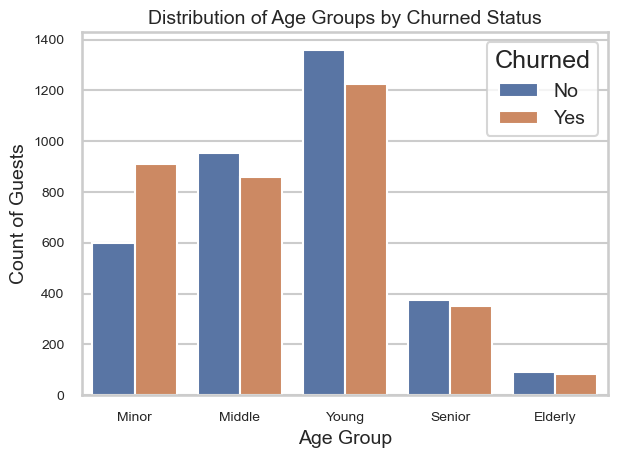

In [104]:
#Generate a figure that compares the AgeGroups to the Churned column. Use a bar graph to show the count of guests in each age group for both churned and non-churned guests.
sns.countplot(data=churn, x='AgeGroup', hue='Churned')
plt.title('Distribution of Age Groups by Churned Status')
plt.xlabel('Age Group')
plt.ylabel('Count of Guests')
plt.legend(title='Churned', labels=['No', 'Yes'])
save_fig("age_group_by_churned_status")
plt.show()

## 4. Is there any information we can get from guests that shared a room?

In [85]:
churn.describe()

,GuestID,AllInclusive,Age,VIP,RoomService,Dining,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,Churned
count,6954.000000,6786.000000,6809.000000,6796.000000,6490.000000,6466.000000,6790.000000,6806.000000,6815.000000,6954.000000,6954.000000,6954.000000,6954.000000
mean,544815.121369,0.358974,28.707299,0.023396,3823.687190,7651.359101,5980.799434,5728.859525,6757.871818,5037.915876,2.994392,183.176877,0.503595
std,258449.781823,0.479735,14.504080,0.151169,26416.086096,54005.989936,43130.400968,41105.729649,46162.309423,2870.166683,1.419025,104.555678,0.500023
min,100000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,322043.250000,0.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2566.250000,2.000000,93.000000,0.000000
50%,542402.500000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5055.500000,3.000000,183.000000,1.000000
75%,769552.750000,1.000000,38.000000,0.000000,84.000000,95.000000,37.750000,80.000000,67.000000,7496.750000,4.000000,273.000000,1.000000
max,999943.000000,1.000000,79.000000,1.000000,282324.947439,590932.008676,468882.332928,447858.846683,482032.266355,9996.000000,5.000000,364.000000,1.000000


In [86]:
#I want to know how many guests shared a room
#Create a new column called "SharedRoom" that is contains a 1 if there is another GuesID that shares the same Room and BookingDate, and 0 otherwise.
churn['SharedRoom'] = churn.duplicated(subset=['Room', 'BookingDate'], keep=False).astype(int)

#Count the number of guests that shared a room
num_shared = churn['SharedRoom'].sum()
print(f'Number of guests that shared a room: {num_shared}')

Number of guests that shared a room: 251


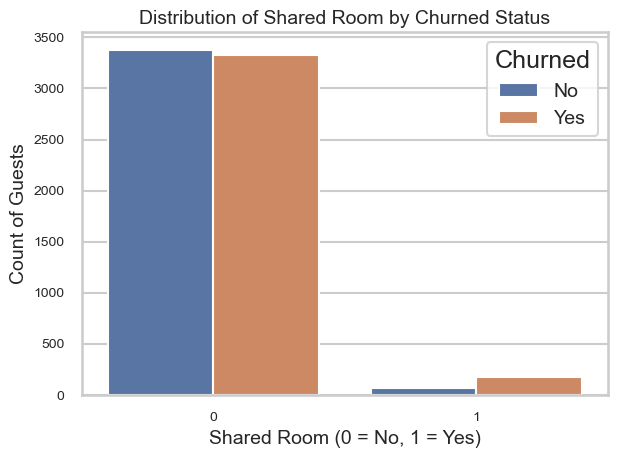

In [87]:
#Create a graph that shows the distribution of the number of guests that shared a room compared to the Churned column. Use a bar graph to show the count of guests that shared a room (SharedRoom = 1) and those that did not share a room (SharedRoom = 0) for both churned and non-churned guests.
sns.countplot(data=churn, x='SharedRoom', hue='Churned')
plt.title('Distribution of Shared Room by Churned Status')
plt.xlabel('Shared Room (0 = No, 1 = Yes)')
plt.ylabel('Count of Guests')
plt.legend(title='Churned', labels=['No', 'Yes'])
save_fig("shared_rooms_by_churned_status") 
plt.show()

## 5. Do promo codes affect churn rates?

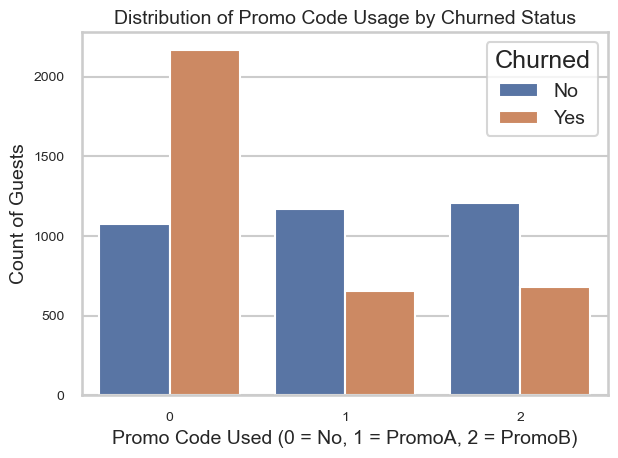

In [88]:
#Create a bar graph that shows whether or not using a PromoCode has an effect on the Churned column. Use a bar graph to show the count of guests that used a promo code (PromoCodeUsed = 1 for "PromoA" and PromoCodeUsed = 2 for "PromoB") and those that did not use a promo code (PromoCodeUsed = 0) for both churned and non-churned guests.
churn['PromoCodeUsed'] = churn['PromoCode'].map({'PromoA': 1, 'PromoB': 2}).fillna(0).astype(int)
sns.countplot(data=churn, x='PromoCodeUsed', hue='Churned')
plt.title('Distribution of Promo Code Usage by Churned Status')
plt.xlabel('Promo Code Used (0 = No, 1 = PromoA, 2 = PromoB)')
plt.ylabel('Count of Guests')   
plt.legend(title='Churned', labels=['No', 'Yes'])
save_fig("promo_code_usage_by_churned_status")
plt.show()

## 6. What can the SurveyScore tell us about churn rates?

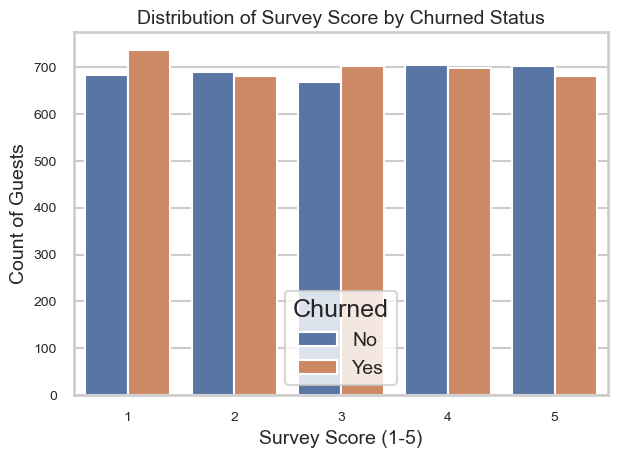

In [89]:
#Create a diagram that compares the SurveyScore column to the Churned column. Use a bar graph to show the count of guests for each SurveyScore (1, 2, 3, 4, 5) for both churned and non-churned guests.
sns.countplot(data=churn, x='SurveyScore', hue='Churned')
plt.title('Distribution of Survey Score by Churned Status')
plt.xlabel('Survey Score (1-5)')
plt.ylabel('Count of Guests')
plt.legend(title='Churned', labels=['No', 'Yes'])
save_fig("survey_score_by_churned_status")
plt.show()

## 7. Do Loyalty Points Matter?

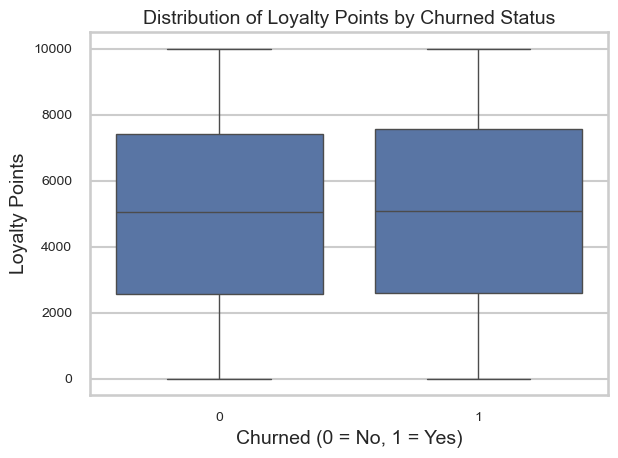

In [90]:
#Generate a figure that compares the Churned to the amount of LoyaltyPoints a customer has. Does the number of LoyaltyPoints a customer has seem to have an effect on whether or not they churned? Use a boxplot to show the distribution of LoyaltyPoints for both churned and non-churned customers.
sns.boxplot(data=churn, x='Churned', y='LoyaltyPoints')
plt.title('Distribution of Loyalty Points by Churned Status')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Loyalty Points')
save_fig("loyalty_points_by_churned_status")
plt.show()




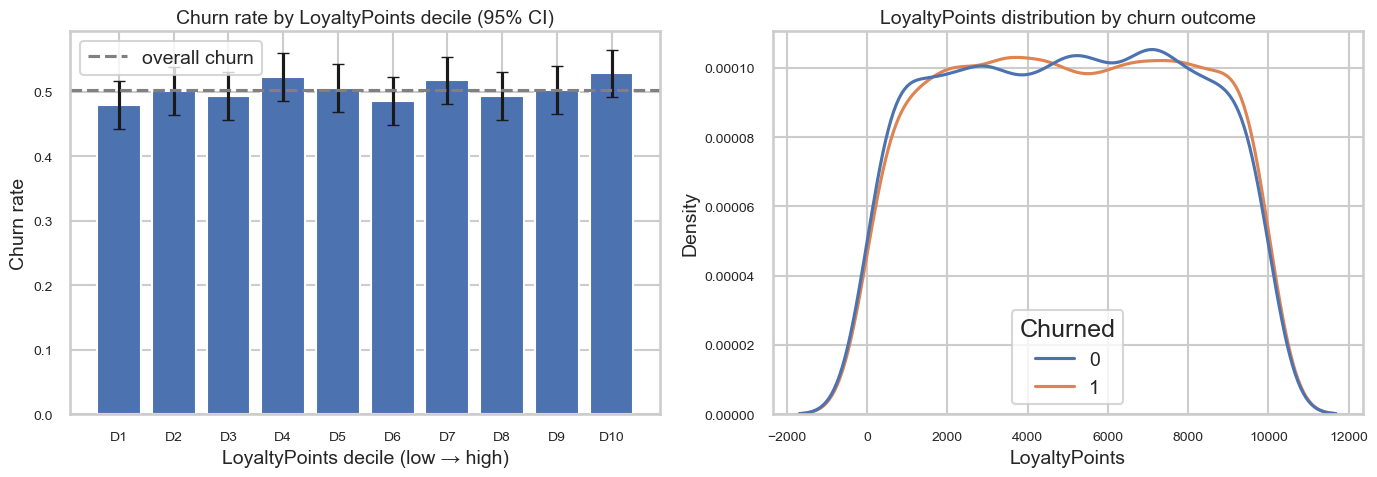

Point-biserial correlation: r=0.011, p=3.50e-01


In [91]:

#import seaborn as sns
#from scipy.stats import pointbiserialr

df = pd.read_csv("churn_cleaned.csv")

# Decile bins of LoyaltyPoints
df["LoyaltyDecile"] = pd.qcut(df["LoyaltyPoints"], q=10, duplicates="drop")
rate = df.groupby("LoyaltyDecile")["Churned"].agg(["mean", "count"])
rate["se"] = np.sqrt(rate["mean"] * (1 - rate["mean"]) / rate["count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Churn rate by loyalty decile
axes[0].bar(range(len(rate)), rate["mean"], yerr=1.96 * rate["se"], capsize=4)
axes[0].set_xticks(range(len(rate)))
axes[0].set_xticklabels([f"D{i+1}" for i in range(len(rate))])
axes[0].set_xlabel("LoyaltyPoints decile (low → high)")
axes[0].set_ylabel("Churn rate")
axes[0].set_title("Churn rate by LoyaltyPoints decile (95% CI)")
axes[0].axhline(df["Churned"].mean(), ls="--", color="gray", label="overall churn")
axes[0].legend()

# 2. Distribution overlay
sns.kdeplot(data=df, x="LoyaltyPoints", hue="Churned", common_norm=False, ax=axes[1])
axes[1].set_title("LoyaltyPoints distribution by churn outcome")

plt.tight_layout()
save_fig("loyalty_points_by_churned_status")
plt.show()

r, p = pointbiserialr(df["LoyaltyPoints"], df["Churned"])
print(f"Point-biserial correlation: r={r:.3f}, p={p:.2e}")


## 8. Do spend amounts affect Churn rates?

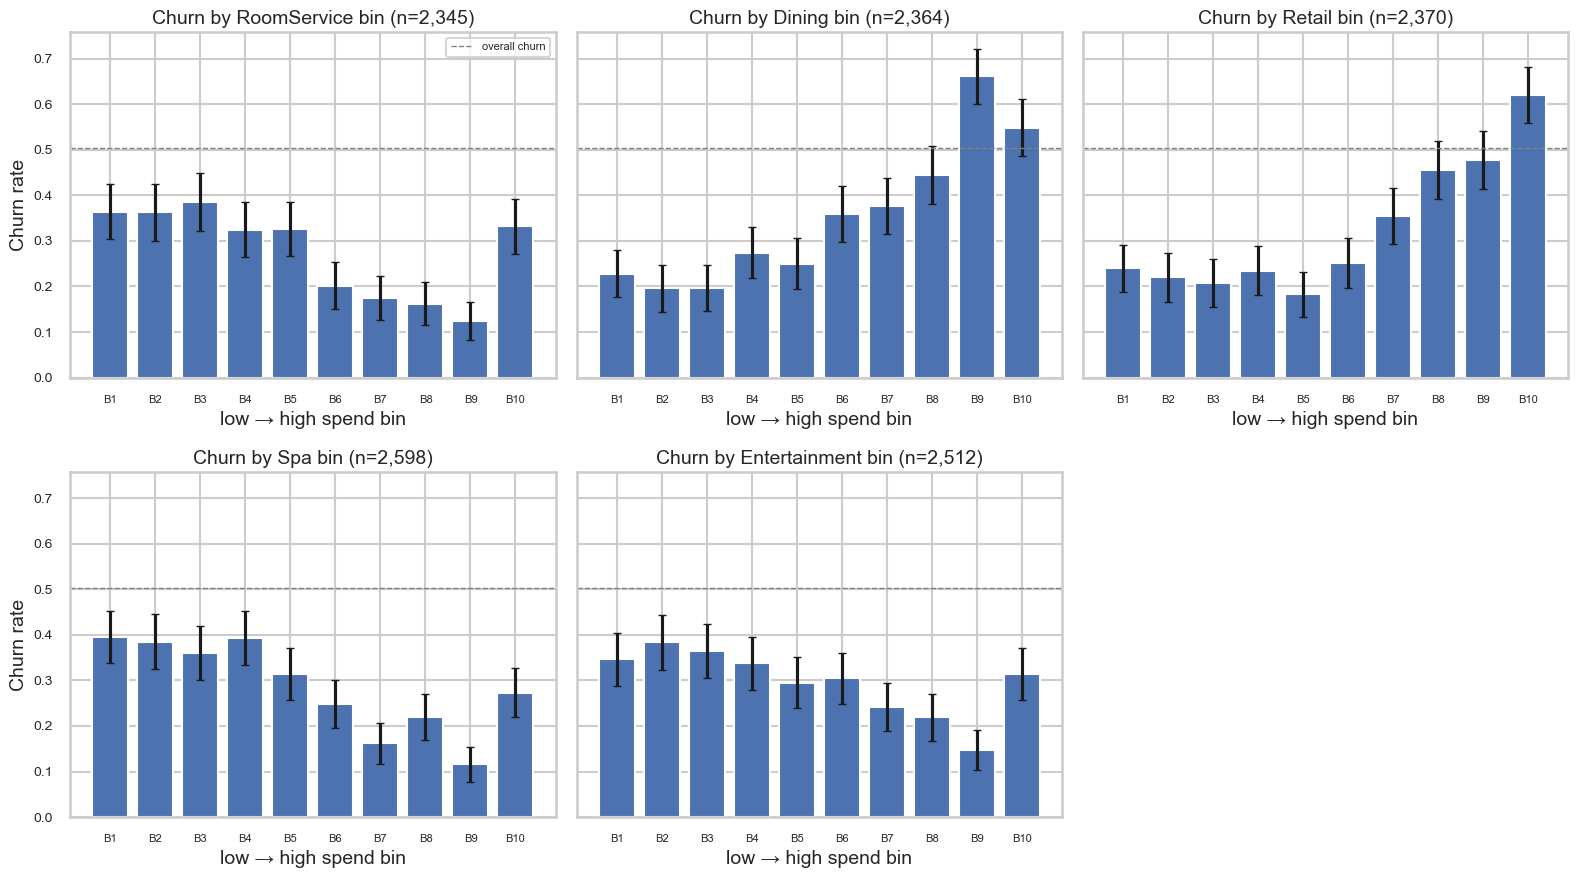

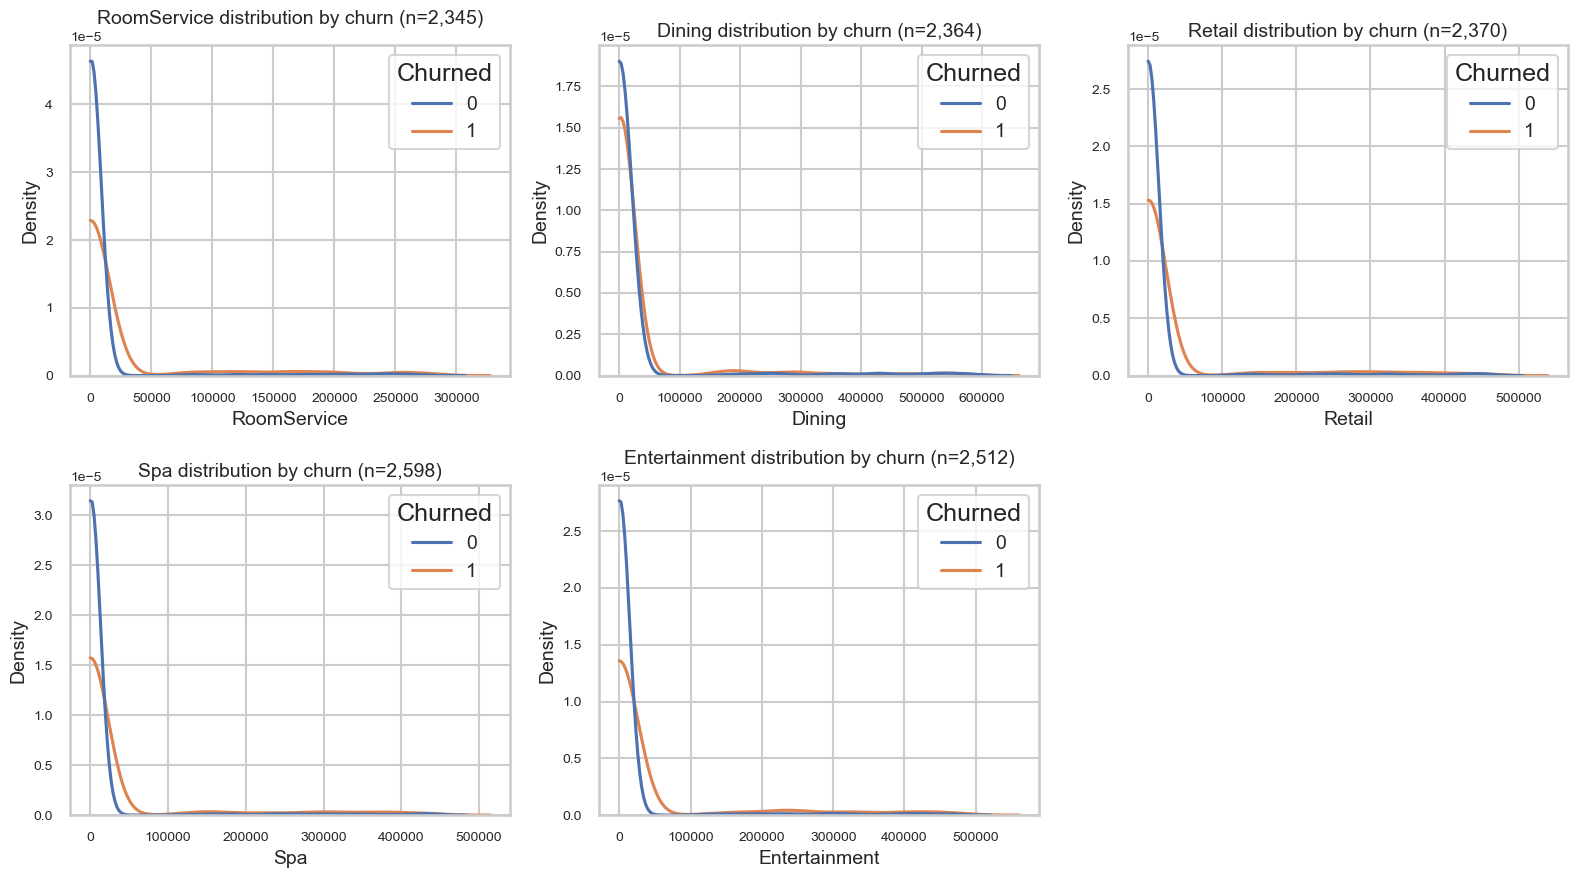

,feature,n_spenders,point_biserial_r,p_value
1,Dining,2364,0.034226,9.616683e-02
2,Retail,2370,0.105798,2.439300e-07
3,Spa,2598,0.109027,2.531572e-08
0,RoomService,2345,0.118390,8.912789e-09
4,Entertainment,2512,0.120979,1.181275e-09


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

df = pd.read_csv("churn_cleaned.csv")
spend_cols = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]
overall = df["Churned"].mean()

def spenders(col):
    sub = df[[col, "Churned"]].dropna()
    return sub[sub[col] > 0]

# --- Grid 1: churn rate by spend decile (spenders only) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
for ax, col in zip(axes.flat, spend_cols):
    sub = spenders(col)
    bins = pd.qcut(sub[col], q=10, duplicates="drop")
    rate = sub.groupby(bins)["Churned"].agg(["mean", "count"])
    rate["se"] = np.sqrt(rate["mean"] * (1 - rate["mean"]) / rate["count"])
    ax.bar(range(len(rate)), rate["mean"], yerr=1.96 * rate["se"], capsize=3)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([f"B{i+1}" for i in range(len(rate))], fontsize=8)
    ax.axhline(overall, ls="--", color="gray", lw=1, label="overall churn")
    ax.set_title(f"Churn by {col} bin (n={len(sub):,})")
    ax.set_xlabel("low → high spend bin")
axes[0, 0].set_ylabel("Churn rate")
axes[1, 0].set_ylabel("Churn rate")
axes[0, 0].legend(fontsize=8)
axes[-1, -1].axis("off")
plt.tight_layout()
save_fig("spend_vs_churn_bars")
plt.show()

# --- Grid 2: distribution overlays (spenders only) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, spend_cols):
    sub = spenders(col)
    sns.kdeplot(data=sub, x=col, hue="Churned", common_norm=False, ax=ax, clip=(0, None))
    ax.set_title(f"{col} distribution by churn (n={len(sub):,})")
axes[-1, -1].axis("off")
plt.tight_layout()
save_fig("spend_vs_churn_distributions")
plt.show()

# --- Correlation summary (spenders only) ---
summary = []
for col in spend_cols:
    sub = spenders(col)
    r, p = pointbiserialr(sub[col], sub["Churned"])
    summary.append({
        "feature": col,
        "n_spenders": len(sub),
        "point_biserial_r": r,
        "p_value": p,
    })
pd.DataFrame(summary).sort_values("point_biserial_r")


## 9. Does buying an All Inclusive package matter?

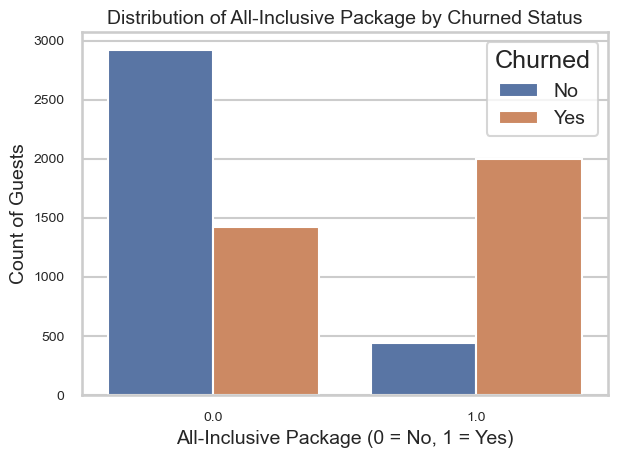

In [95]:
#Generate a diagram that compares churned to whether they purchase an AllInclusive package. Use a bar graph to show the count of guests that purchased an All-Inclusive package (AllInclusive = 1) and those that did not purchase an All-Inclusive package (AllInclusive = 0) for both churned and non-churned guests.
sns.countplot(data=churn, x='AllInclusive', hue='Churned')
plt.title('Distribution of All-Inclusive Package by Churned Status')
plt.xlabel('All-Inclusive Package (0 = No, 1 = Yes)')
plt.ylabel('Count of Guests')
plt.legend(title='Churned', labels=['No', 'Yes'])
save_fig("all_inclusive_by_churned_status")
plt.show()

## 10. Does the package type purchased matter?

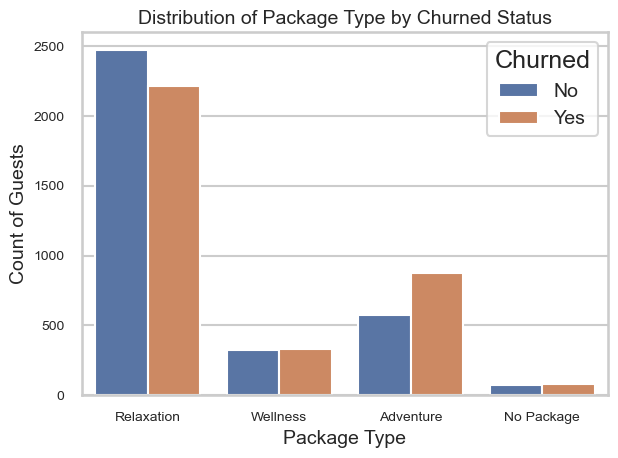

In [99]:
#Compare the PackageType purchased versus the Churned column. The options for PackageType are "Adventure", "Relaxation", and "Wellness". If null, assume a "No Package". Use a bar graph to show the count of guests that purchased each package type for both churned and non-churned guests.

churn['PackageType'] = churn['PackageType'].fillna('No Package')
sns.countplot(data=churn, x='PackageType', hue='Churned')
plt.title('Distribution of Package Type by Churned Status')
plt.xlabel('Package Type')
plt.ylabel('Count of Guests')
plt.legend(title='Churned', labels=['No', 'Yes'])
save_fig("package_type_by_churned_status")
plt.show()

## 11. Are responsive people more like to churn?

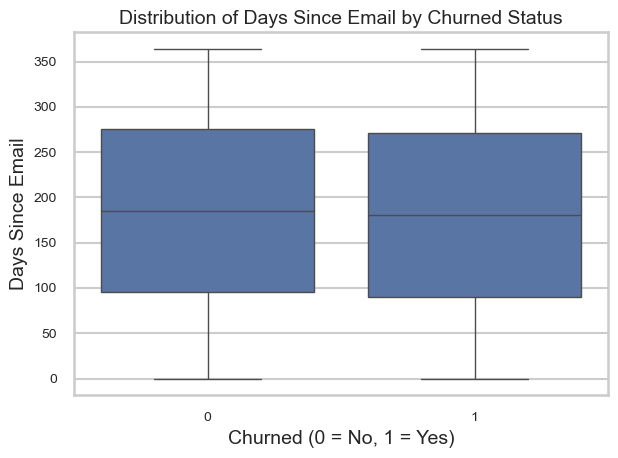

In [101]:
#generate a figure that compares DaysSinceEmail to Churned. Use a deciles to show the distribution of DaysSinceEmail for both churned and non-churned customers.
churn['DaysSinceEmail_Decile'] = pd.qcut(churn['DaysSinceEmail'], q=10, labels=False)
sns.boxplot(data=churn, x='Churned', y='DaysSinceEmail')
plt.title('Distribution of Days Since Email by Churned Status')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Days Since Email')
save_fig("days_since_email_by_churned_status")
plt.show()

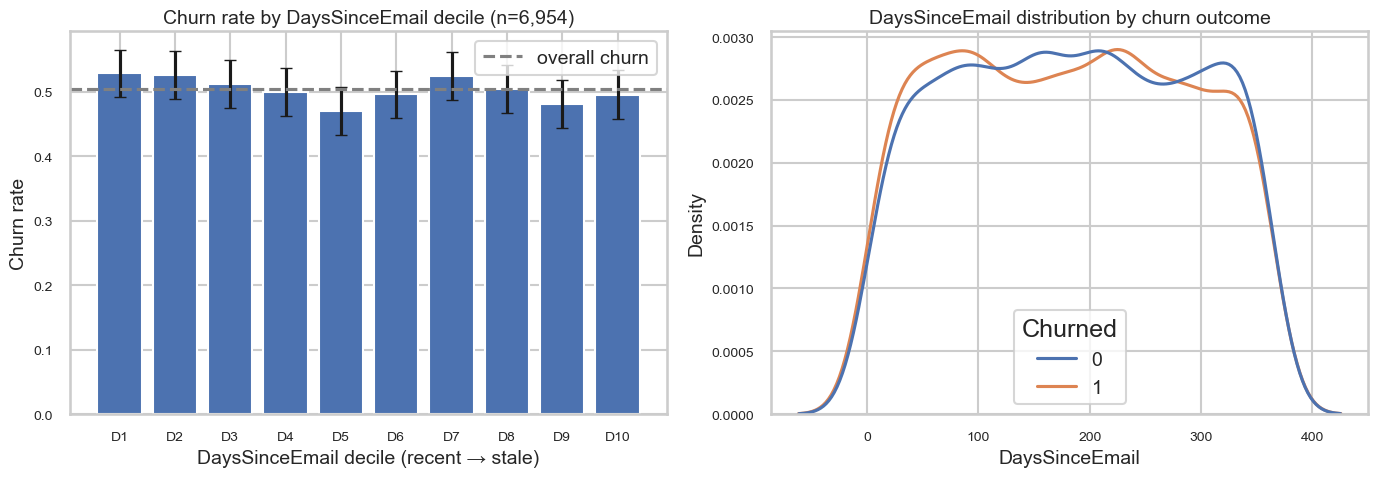

Point-biserial correlation: r=-0.018, p=1.28e-01  (n=6,954)


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

df = pd.read_csv("churn_cleaned.csv")
sub = df[["DaysSinceEmail", "Churned"]].dropna()
overall = sub["Churned"].mean()

# Decile bins
sub["Bin"] = pd.qcut(sub["DaysSinceEmail"], q=10, duplicates="drop")
rate = sub.groupby("Bin")["Churned"].agg(["mean", "count"])
rate["se"] = np.sqrt(rate["mean"] * (1 - rate["mean"]) / rate["count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Churn rate by DaysSinceEmail decile
axes[0].bar(range(len(rate)), rate["mean"], yerr=1.96 * rate["se"], capsize=4)
axes[0].set_xticks(range(len(rate)))
axes[0].set_xticklabels([f"D{i+1}" for i in range(len(rate))])
axes[0].set_xlabel("DaysSinceEmail decile (recent → stale)")
axes[0].set_ylabel("Churn rate")
axes[0].set_title(f"Churn rate by DaysSinceEmail decile (n={len(sub):,})")
axes[0].axhline(overall, ls="--", color="gray", label="overall churn")
axes[0].legend()

# 2. Distribution overlay
sns.kdeplot(data=sub, x="DaysSinceEmail", hue="Churned", common_norm=False, ax=axes[1])
axes[1].set_title("DaysSinceEmail distribution by churn outcome")

plt.tight_layout()
save_fig("days_since_email_by_churned_status_deciles")
plt.show()

r, p = pointbiserialr(sub["DaysSinceEmail"], sub["Churned"])
print(f"Point-biserial correlation: r={r:.3f}, p={p:.2e}  (n={len(sub):,})")


## 12. Doesbooking types and referral sources matter?

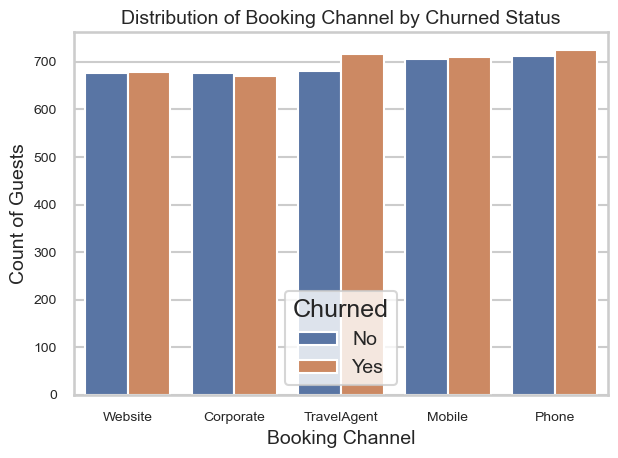

In [106]:
#Generate a figure that compares the BookingChannel to the Churned column. The options for BookingChannel are "Corporate", "Phone", "TravelAgent", "Website", and "Mobile". Use a bar graph to show the count of guests that booked through each booking channel for both churned and non-churned guests.   
sns.countplot(data=churn, x='BookingChannel', hue='Churned')
plt.title('Distribution of Booking Channel by Churned Status')
plt.xlabel('Booking Channel')
plt.ylabel('Count of Guests')
plt.legend(title='Churned', labels=['No', 'Yes'])
save_fig("booking_channel_by_churned_status")
plt.show()

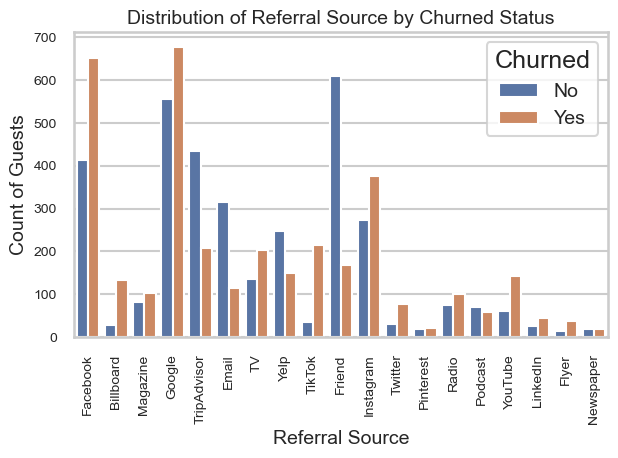

In [109]:
#Generate a figure that compares the BookingChannel to the Churned column. Use a bar graph to show the count of guests that booked through each booking channel for both churned and non-churned guests. The labels on the x axis should be titled 45 degrees and should be the actual names of the referral sources.
sns.countplot(data=churn, x='ReferralSource', hue='Churned')
plt.title('Distribution of Referral Source by Churned Status')
plt.xlabel('Referral Source')
plt.ylabel('Count of Guests')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.xticks(rotation=90)
save_fig("referral_source_by_churned_status")
plt.show()

## Overall Histogram plots and export cleaned data

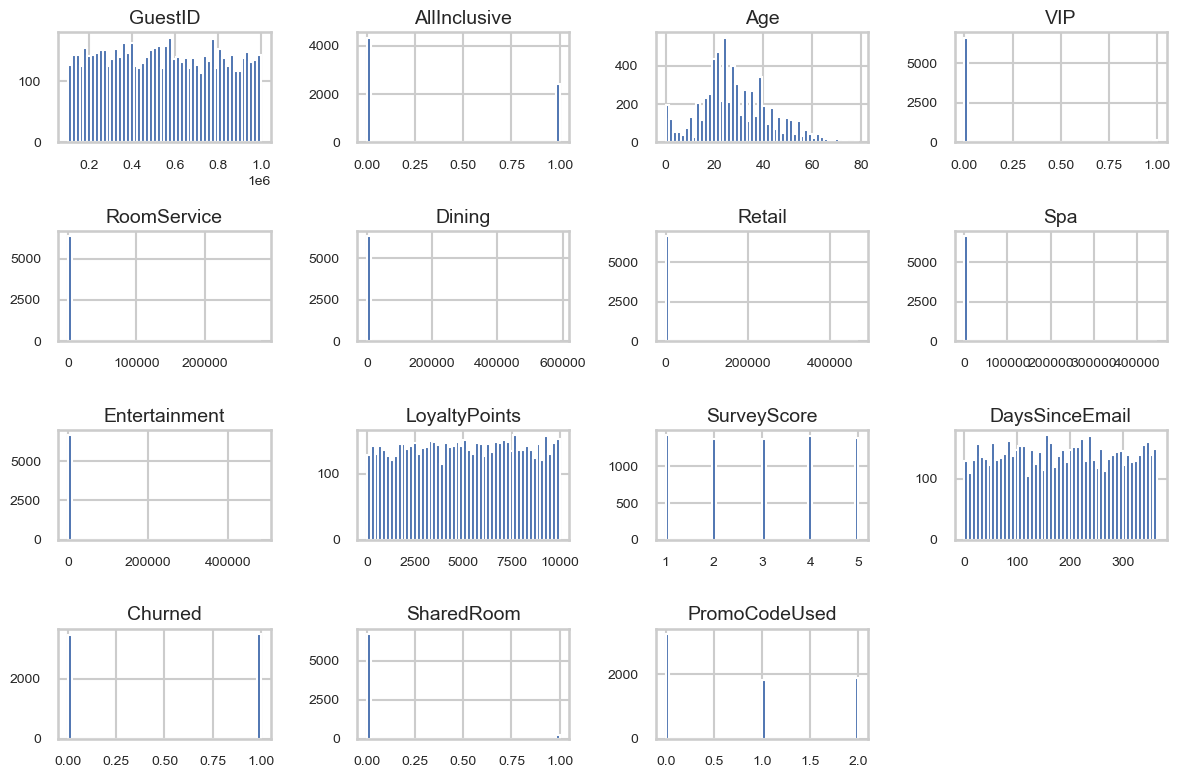

In [97]:
churn.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

In [94]:
#Export the churned data to a csv file called "churn_cleaned.csv"
churn.to_csv("churn_cleaned.csv", index=False)


